In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd 
import pandas as pd

In [42]:
# Set display format
# pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
project_root = Path.cwd()
if not Path('data').exists():
    project_root = project_root.parent
print(project_root)

d:\Wu\2026\Project Portfolio\003 Project\grocery-demand-estimation


### Load spatial data

In [3]:
demand_path = project_root / 'data/processed/potential_grocery_demand.gpkg'
city_path = project_root / 'data/processed/kootenai_cities.gpkg'

In [5]:
demand = gpd.read_file(demand_path, layer='tract_demand')
city = gpd.read_file(city_path, layer='cities')

### Inspect demand distribution

In [43]:
demand['potential_grocery_deman'].describe().round(0).map("{:,.0f}".format)

count            39
mean     11,169,097
std       4,648,388
min       3,324,258
25%       7,641,704
50%      10,703,059
75%      13,827,278
max      22,457,729
Name: potential_grocery_deman, dtype: str

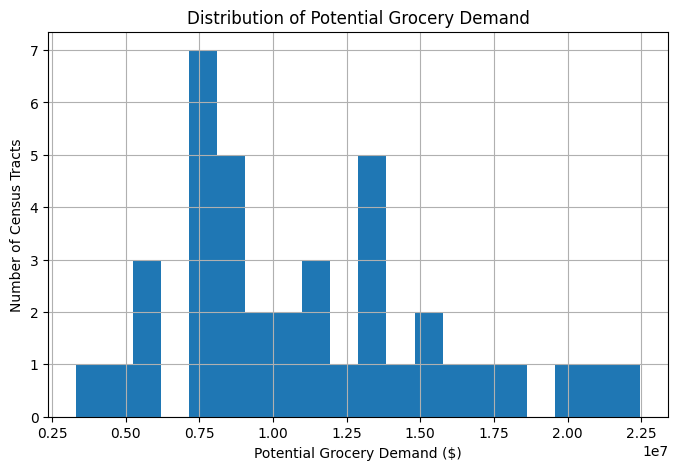

In [44]:
demand['potential_grocery_deman'].hist(
    bins=20, figsize=(8,5)
)
plt.xlabel('Potential Grocery Demand ($)')
plt.ylabel('Number of Census Tracts')
plt.title('Distribution of Potential Grocery Demand')
plt.show()

### Classify the demand

In [18]:
demand.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'state', 'county', 'tract', 'household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery', 'potential_grocery_deman',
       'geometry'],
      dtype='str')

In [28]:
# create demand classes
# divide tracts into equal-width-demand groups  
demand['demand_class'] = pd.cut(
    demand['potential_grocery_deman'],
    bins=4,
    labels = ['low', 'medium', 'high', 'very high'],
    include_lowest=True
) 

demand[['potential_grocery_deman', 'demand_class']].head()

,potential_grocery_deman,demand_class
0,"5,874,592",low
1,"8,448,130",medium
2,"10,849,116",medium
3,"19,928,021",very high
4,"15,493,730",high


In [29]:
demand['demand_class'].value_counts()

demand_class
medium       13
low          12
high         10
very high     4
Name: count, dtype: int64

### Summarize demograhics by demand class

In [32]:
demo_list = ['household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery']

demand_summary = demand.groupby('demand_class')[demo_list].mean()
demand_summary

,household_count,avg_household_size,median_income,median_age,owner_rate,college_plus_pct,avg_grocery
demand_class,,,,,,,
low,"1,115",2,"81,794",48,76,32,"5,872"
medium,"1,624",3,"82,255",44,68,30,"6,193"
high,"2,342",3,"87,769",43,75,31,"6,354"
very high,"3,315",3,"86,767",37,71,28,"6,162"


### Correlation Analysis

In [34]:
corr_df = demand[demo_list + ['potential_grocery_deman']]

In [40]:
corr_matrix = corr_df.corr()
demand_corr = (
    corr_matrix['potential_grocery_deman']
    .drop('potential_grocery_deman')
    .sort_values(ascending=False)
)
demand_corr.round(2)
demand_corr

household_count       0.97
avg_household_size    0.28
avg_grocery           0.20
median_income         0.12
owner_rate           -0.04
college_plus_pct     -0.14
median_age           -0.46
Name: potential_grocery_deman, dtype: float64

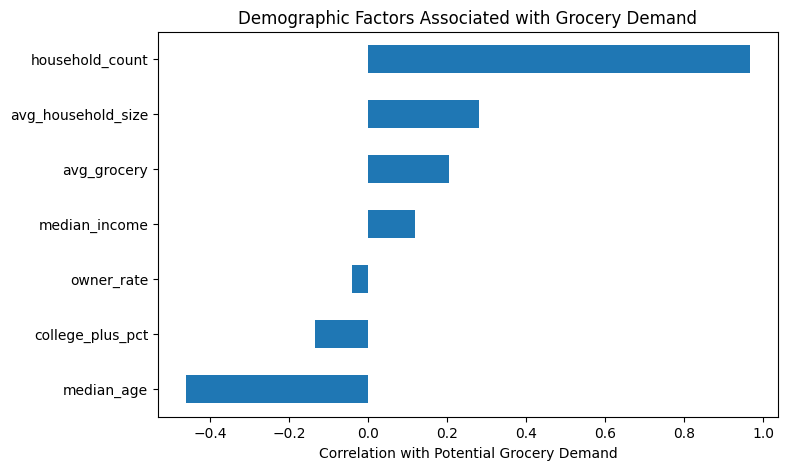

In [36]:
demand_corr.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel("Correlation with Potential Grocery Demand")
plt.title("Demographic Factors Associated with Grocery Demand")
plt.show()

### Household level grocery expenditure analysis

#### Correlation 

In [47]:
demand[
    [
        "median_income",
        "median_age",
        "owner_rate",
        "college_plus_pct",
        "avg_household_size",
        "avg_grocery"
    ]
].corr()["avg_grocery"].sort_values()

median_age           0.23
avg_household_size   0.35
college_plus_pct     0.41
owner_rate           0.64
median_income        0.83
avg_grocery          1.00
Name: avg_grocery, dtype: float64